# Experiment A1: parse JSF
Lets try to read one of the JSF files. Interpret them using this spec:
  https://www.edgetech.com/wp-content/uploads/2019/07/0023492_Rev_E.pdf

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
import sys
import gc


#%pip install opencv-python


import glob
import cv2

from tqdm import tqdm

from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Message definition

In [3]:
import struct

In [4]:
header_format = [
    {"struct_type": "H", "dtype": "UINT16", "field_name": "synch_marker"      , "description": "Synch Marker, always 0x1601"},
    {"struct_type": "B", "dtype": "UINT8" , "field_name": "protocol_version"  , "description": "Protocol version"},
    {"struct_type": "B", "dtype": "UINT8" , "field_name": "session_identifier", "description": "Session identifier"},
    {"struct_type": "H", "dtype": "UINT16", "field_name": "message_type"      , "description": "Message type"},
    {"struct_type": "B", "dtype": "UINT8" , "field_name": "command_type"      , "description": "Command type"},
    {"struct_type": "B", "dtype": "UINT8" , "field_name": "subsystem_number"  , "description": "Subsystem number"},
    {"struct_type": "B", "dtype": "UINT8" , "field_name": "channel"           , "description": "Channel 0=port, 1=starboard"},
    {"struct_type": "B", "dtype": "UINT8" , "field_name": "sequence_number"   , "description": "Sequence number"},
    {"struct_type": "H", "dtype": "UINT16", "field_name": "reserved"          , "description": "Reserved"},
    {"struct_type": "i", "dtype": "INT32" , "field_name": "payload_length"    , "description": "Payload message length"}
]

struct_fmt = "".join([h['struct_type'] for h in header_format])
struct_len = struct.calcsize(struct_fmt)
struct_unpack = struct.Struct(struct_fmt).unpack_from


## Read all message from a single file

In [5]:
def decode_message(unpacked_struct):
    message = {}
    for i in range(len(unpacked_struct)):
        field_name = header_format[i]['field_name']
        field_value = unpacked_struct[i]
        message[field_name] = field_value
        
    return message


messages = []
#counter = 0
with tqdm() as p, open("data/20200107101600.jsf", 'rb') as fp:
    while True:
        data = fp.read(struct_len)
        if not data:
            break
            
        unpacked_struct = struct_unpack(data)
        message = decode_message(unpacked_struct)
        message['payload'] = fp.read(message['payload_length'])
        #print(message)
        #counter += 1
        #if counter == 3: break
        messages.append(message)
        p.update()
        

11150it [00:00, 35626.29it/s]


## Inspect messages
According to this site the 4125 Sonar should be able to send the following message types:
https://ge0mlib.com/download.htm
```
Type	Description
40      Acoustic Return Data
80      Sonar Data Message
181     Navigation offsets
182     System information
1065	?
2002	NMEA string
2020	Pitch Roll Data
2040	?
2060	Pressure Sensor Reading
```

In [6]:
df = pd.DataFrame(messages)
#print(messages[0:2])
print(len(messages))
print(np.frombuffer(df[df.message_type == 2002].iloc[56].payload[8:9], dtype=np.int8))
print(df[df.message_type == 2002].iloc[56])
print(df)

11150
[3]
synch_marker                                                       5633
protocol_version                                                     16
session_identifier                                                    0
message_type                                                       2002
command_type                                                          2
subsystem_number                                                    100
channel                                                               4
sequence_number                                                       0
reserved                                                              0
payload_length                                                       84
payload               b'\xaaZ\x14^\x8b\x01\x00\x00\x03\x00\x00\x00$G...
Name: 965, dtype: object
       synch_marker  protocol_version  session_identifier  message_type  \
0              5633                14                   0           182   
1              5633    

In [7]:
print("Message_type counts")
df.message_type.value_counts().sort_index()

Message_type counts


40        49
80      7818
181        1
182        5
2002     646
2020    1113
2040     759
2060     759
Name: message_type, dtype: int64

In [8]:
print("Sonar Data Message (type 80) message count per channel")
df[df.message_type == 80].channel.value_counts()

Sonar Data Message (type 80) message count per channel


0    3909
1    3909
Name: channel, dtype: int64

In [9]:
print("Statistics per message type")


combi = df[['message_type', 'payload_length']].groupby('message_type').sum()

combi['count'] = df.message_type.value_counts().sort_index()
combi['average_length'] = df[['message_type', 'payload_length']].groupby('message_type').mean().round()

print(combi)

combi['count'] = df.message_type.value_counts().sort_index()
combi['average_length'] = df[['message_type', 'payload_length']].groupby('message_type').mean().round()
combi['payload_sample'] = pd.Series(
    data=[
        df[df.message_type == message_type].payload.values[0].decode('latin-1', errors='replace')
        for message_type in sorted(df.message_type.unique())],
    index=sorted(df.message_type.unique())
)

combi

Statistics per message type
              payload_length  count  average_length
message_type                                       
40                      4900     49           100.0
80                  52005336   7818          6652.0
181                       64      1            64.0
182                    67120      5         13424.0
2002                   43872    646            68.0
2020                   48972   1113            44.0
2040                   27324    759            36.0
2060                   57684    759            76.0


,payload_length,count,average_length,payload_sample
message_type,,,,
40,4900,49,100.0,    7             9 (ÃF          ...
80,52005336,7818,6652.0,"Z^    ;      ""   -       ?         Up  ..."
181,64,1,64.0,                                              ...
182,67120,5,13424.0,               kÀ                       ...
2002,43872,646,68.0,"¡Z^´      $GPZDA,101705.000,07,01,2020,,*52\n "
2020,48972,1113,44.0,Z^á                þ#       dÀ      
2040,27324,759,36.0,Z^T      ®ÀoàÞ hûFh«C?t        
2060,57684,759,76.0,Z^T      Þ=                               ...


## Visualize *Sonar Trace Data* from  Data Message (type 80) payload
From the IRS:

2.2.1 Message Type 80: Sonar Data Message (jsfdefs.h)
The Sonar Data Message consists of a single channel ping of data (receiver sounding period) for a single
channel (e.g., port side of low frequency side scan subsystem). Most side scan subsystems have two data
channels: port and starboard. Most sub-bottom subsystems have a single data channel. Which fields have
data present depends on the system used and data acquisition procedures. In addition, this message may
contain data from multiple non-acoustic sensors. Non-acoustic data contained in this message normally
is not time interpolated.
EdgeTech strongly recommends that if high positional or situational accuracy is required, the individual
sensor messages should be processed instead (see sub-section 2.4 AUXILIARY MESSAGES). Otherwise, this
may be the only message that needs to be interpreted in a JSF file if the level of accuracy is sufficient. The
Validity Flag field (byte 30-31) indicates which auxiliary fields are populated. By convention, if a value is
not present, the field is set to 0.
A Sonar Data Message consists of a 240-byte header followed by the actual acoustic sample data. This
240-byte header is described in the table below.

(SKIP)

**Sonar trace data** follows the 240-byte header and consists of 16-bit integer values. The number of integers
to be read is found by multiplying the number of samples in the trace (bytes 114-115) by the number of
integers per sample for the data type used (1 or 2). Furthermore, doubling this yields the byte size of the
data section. This should exactly match the preceding Message Header byte count (bytes 12 –15) less the
header size of 240.

In [10]:
# Simple RAW decode of the Sonar Trace Data from a single sensor side (0=port, 1=starboard)
SENSOR_SIDE = 0

def decode_sonar_trace_data(m):
    sonar_message_header_length = 240
    timestamp = np.frombuffer(m['payload'][:4], dtype=np.int32)[0]
    validities = np.frombuffer(m['payload'][30:32], dtype=np.uint16)[0]
    speed_valid = (validities & 1 << 2) > 0
    speed = np.frombuffer(m['payload'][194:196], dtype=np.int16)[0] if speed_valid else None
    
    if speed is not None:
        # Convert 1/10 knots to km/h
        speed = (speed * 0.051).round(2)
    
    data = m['payload'][sonar_message_header_length:]
    data = np.frombuffer(data, dtype=np.int16)
    return {'timestamp': timestamp,
            'speed': speed,
            'sonar_trace_data': data}


port_payloads = []
starboard_payloads = []
for m in tqdm(messages):
    if m['message_type'] == 80 and m['channel'] == 0:
        port_payloads.append(decode_sonar_trace_data(m))
    if m['message_type'] == 80 and m['channel'] == 1:
        starboard_payloads.append(decode_sonar_trace_data(m))
 

100%|█████████████████████████████████████████████████████████████████████████| 11150/11150 [00:00<00:00, 26914.54it/s]


In [11]:
payloads = starboard_payloads + port_payloads
len(payloads)    

payloads_df = pd.DataFrame(payloads, columns=['timestamp', 'speed'])
payloads_df['date'] = pd.to_datetime(payloads_df.timestamp, unit='s')
#print(payloads)

In [12]:
print(f"Recording start    : {payloads_df.date.min()}")
print(f"Recording end      : {payloads_df.date.max()}")
print(f"Recording duration : {payloads_df.date.max()-payloads_df.date.min()}")

mean_speed = payloads_df.speed.mean()
total_seconds = (payloads_df.date.max()-payloads_df.date.min()).total_seconds()
travel_distance = mean_speed * total_seconds
print(f"Travel distance    : ~{travel_distance:1.2f} meters")

Recording start    : 2020-01-07 10:17:04
Recording end      : 2020-01-07 10:18:55
Recording duration : 0 days 00:01:51
Travel distance    : ~112.99 meters


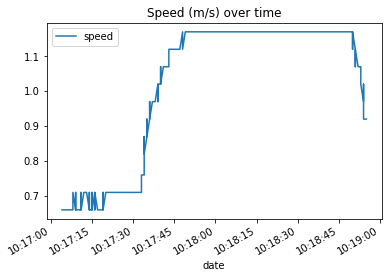

In [13]:
_ = payloads_df.plot(x='date', y='speed', title='Speed (m/s) over time')

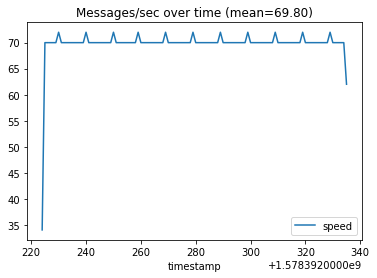

In [14]:
messages_per_sec_over_time = payloads_df[['timestamp', 'speed']].groupby('timestamp').count()
_ = messages_per_sec_over_time.plot(
    title=f'Messages/sec over time (mean={messages_per_sec_over_time.mean().values[0]:0.2f})')

In [15]:
resolution_change_index = []
for i in range(len(payloads)-1):
    if payloads[i]['sonar_trace_data'].shape != payloads[i+1]['sonar_trace_data'].shape:
        resolution_change_index.append(i+1)
# Concat all trace data

trace_data_list = []
if len(resolution_change_index) != 0:
    last_index = 0
    for i in resolution_change_index:
        trace_data_list.append(np.stack([i['sonar_trace_data'] for i in payloads[last_index:i]]))
        last_index = i
    trace_data_list.append(np.stack([i['sonar_trace_data'] for i in payloads[last_index:]]))
else:
    trace_data_concat = np.stack([i['sonar_trace_data'] for i in payloads])

if len(trace_data_list)>0:
    trace_data_concat = trace_data_list[1]

print(f"Data shape : {trace_data_concat.shape}")
print(f"Vmin       : {trace_data_concat.min()}")
print(f"Vmax       : {trace_data_concat.max()}")

Data shape : (7818, 3206)
Vmin       : 0
Vmax       : 31744


In [16]:
N_METERS = 10
sample_count = int(trace_data_concat.shape[0] * N_METERS / travel_distance)

sample_count = int(trace_data_concat.shape[0])


pic = trace_data_concat[:sample_count, :sample_count]

#print(f"Small sample (~{N_METERS} meters)")
print(pic.shape)
pic = cv2.normalize(pic, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
pic = cv2.applyColorMap(pic, cv2.COLORMAP_PINK)
pic = cv2.cvtColor(pic, cv2.COLOR_BGR2RGB)
#cv2.imwrite("sonar3.jpg",pic)
#display(Image.fromarray(pic))


(7818, 3206)


In [17]:
# Some of this is repurposed code from before
def decode_message(unpacked_struct):
    message = {}
    for i in range(len(unpacked_struct)):
        field_name = header_format[i]['field_name']
        field_value = unpacked_struct[i]
        message[field_name] = field_value
        
    return message

def read_messages_from_file(jsf_filename): # format: "data/20200107101600.jsf"
    messages = []
    with open(jsf_filename, 'rb') as fp:
        while True:
            data = fp.read(struct_len)
            if not data:
                break

            unpacked_struct = struct_unpack(data)
            message = decode_message(unpacked_struct)
            message['payload'] = fp.read(message['payload_length'])
            messages.append(message)
    return messages
        
        
def decode_sonar_trace_data_light(m):
    sonar_message_header_length = 240
    timestamp = np.frombuffer(m['payload'][:4], dtype=np.int32)[0]
    data = m['payload'][sonar_message_header_length:]
    data = np.frombuffer(data, dtype=np.int16)
    scaling_factor = np.frombuffer(m['payload'][168:170], dtype=np.int16)[0]
    data = data.astype(float) * 2.0 ** (-scaling_factor) 
    return {'timestamp': timestamp,
            'sonar_trace_data': data}

def get_starboard_and_port_data_from_messages(input_messages):
    port_payloads = []
    starboard_payloads = []
    for fm in input_messages:
        if fm['message_type'] == 80 and fm['channel'] == 0:
            port_payloads.append(decode_sonar_trace_data_light(fm))
        if fm['message_type'] == 80 and fm['channel'] == 1:
            starboard_payloads.append(decode_sonar_trace_data_light(fm))
            
    port_payloads = sorted(port_payloads, key=lambda date: date['timestamp']) # sorts them by date
    starboard_payloads = sorted(starboard_payloads, key=lambda date: date['timestamp'])
    return [port_payloads,starboard_payloads]
        
def split_into_training_data(configuration,full_unsplit_trace):
    target_folder_path = configuration["output_folder_path"]
    sonar_side = configuration["sonar_side"]
    sample_dims = configuration["output_image_dims"] # Height x width
    sample_overlap = configuration["output_image_overlap"]
    
    dim1 = full_unsplit_trace.shape[0]
    dim2 = full_unsplit_trace.shape[1]

    dim1_full = sample_overlap[0] + sample_dims[0]
    dim2_full = sample_overlap[1] + sample_dims[1]
    sample_index = 0

    bottom_repeat_flag = False # the bottom repeat flag stops the last bottom row from sometimes being duplicated
    # depending on the h and w resolution
    for dim1_count in tqdm(range(0, dim1, sample_dims[0])):
        break_flag = False # the break flag stops the last element of any row being duplicated
        
        for dim2_count in range(0, dim2, sample_dims[1]):
            if break_flag: break
            dim1_iter = dim1_count
            dim2_iter = dim2_count
            if (dim1_iter+dim1_full > dim1): # if its over the edge of the image go from the edge back
                dim1_iter = dim1 - dim1_full # it will overlap but its better than losing content
                bottom_repeat_flag = True
            else:
                bottom_repeat_flag = False
            if (dim2_iter+dim2_full > dim2):  # (probably) FIX THIS; SOMETIMES DUPLICATES
                dim2_iter = dim2 - dim2_full
                break_flag = True
            pic = full_unsplit_trace[dim1_iter:dim1_iter+dim1_full,dim2_iter:dim2_iter+dim2_full]
            if pic.shape[0] != dim1_full or pic.shape[1] != dim2_full:
                print("Error, format of trace:{}".format(full_unsplit_trace.shape))
                print("iteration {}/{} with {} to {} and {} to {}".format(dim1_count,dim2_count,dim1_iter,dim1_iter+dim1_full,dim2_iter,dim2_iter+dim2_full))
                print("incorrect format {} x {}".format(pic.shape[0],pic.shape[1]))

            cv2.imwrite("{}/{}_{}_training_image_{}x{}_{}.jpg".format(target_folder_path,target_folder_path.split("/")[1],sonar_side,dim1_full,dim2_full,sample_index),pic)
            sample_index += 1
        if bottom_repeat_flag: break

def scale_image(open_cv_img,fixed_val_w, dynamic = False):
    height = open_cv_img.shape[0]
    if dynamic:
        width = open_cv_img.shape[1]
        var_borders_regions = [0,int(0.33*width),int(0.66*width),width]
        var_weights_regions = [int(fixed_val_w*0.30),int(fixed_val_w*0.30),int(fixed_val_w*0.40)]
        section_1 = open_cv_img[:,var_borders_regions[0]:var_borders_regions[1]].copy()
        section_2 = open_cv_img[:,var_borders_regions[1]:var_borders_regions[2]].copy()
        section_3 = open_cv_img[:,var_borders_regions[2]:var_borders_regions[3]].copy()

        open_cv_img_hcon = [1,2,3]
        open_cv_img_hcon[0] = cv2.resize(section_1,(var_weights_regions[0],height),interpolation = cv2.INTER_AREA)
        open_cv_img_hcon[1] = cv2.resize(section_2,(var_weights_regions[1],height),interpolation = cv2.INTER_AREA)
        open_cv_img_hcon[2] = cv2.resize(section_3,(var_weights_regions[2],height),interpolation = cv2.INTER_AREA)
        del open_cv_img
        gc.collect()
        open_cv_img_res = cv2.hconcat([open_cv_img_hcon[0],open_cv_img_hcon[1],open_cv_img_hcon[2]])
    else:
        open_cv_img_res = cv2.resize(open_cv_img,(fixed_val_w,height),interpolation = cv2.INTER_AREA)
    return open_cv_img_res

def pad_image_width(input_2d_scan,width_val):
    if width_val == input_2d_scan.shape[1]: return input_2d_scan
    empty_mat = np.zeros((input_2d_scan.shape[0],width_val-input_2d_scan.shape[1]))
    result_arr = cv2.hconcat([input_2d_scan,empty_mat])
    return result_arr
    
    
#np.set_printoptions(threshold=sys.maxsize)
def shift_average(input_list, target_average):
    list_mean = np.nanmean(input_list)
    if list_mean == 0: 
        scale_factor = np.single(0)
    else:
        scale_factor = target_average/np.nanmean(input_list)
    scale_factor = scale_factor.astype(float)
    return_list = input_list * scale_factor
    return return_list

def adaptive_norm(input_img_arr1,columns_to_norm_together,norm_max1): # not used anymore due to inferior results
    pic = input_img_arr1
    width = pic.shape[1]
    if columns_to_norm_together == 0:
        cv2.normalize(pic, pic, 0, norm_max1, cv2.NORM_MINMAX)
        return pic
    
    for width_pixel in range(columns_to_norm_together,width,columns_to_norm_together):
        prev_pixel = width_pixel-columns_to_norm_together
        percent_complete = width_pixel / width
        increasing_norm_coeficient = 1.0 #+ percent_complete
        cv2.normalize(pic[:,prev_pixel:width_pixel], pic[:,prev_pixel:width_pixel], 0, norm_max1, cv2.NORM_MINMAX)
    
    cv2.normalize(pic[:,900:], pic[:,900:], 0, norm_max1, cv2.NORM_MINMAX)
    return pic
    

def auto_gain_control(input_img_arr,average_val,mode="rows"):
    #https://chesapeaketech.com/wp-content/uploads/docs/SonarWiz7_UG/HTML/automatic_gain_control__agc_.html
    defined_average = average_val #1.5 used when using min-max norm
    if mode == "rows": #global row average shift
        result_val = np.zeros(input_img_arr.shape)
        img_arr_iter = input_img_arr
        for index,row in enumerate(img_arr_iter):
            result_val[index] = shift_average(row,defined_average)
        return result_val
    else: 
        input_img_arr = np.transpose(input_img_arr)
        result_val = np.zeros(input_img_arr.shape)
        absolute_index = 0
        img_arr_iter = input_img_arr
        for row in img_arr_iter:
            result_val[absolute_index] = shift_average(row,defined_average)
            absolute_index += 1
        result_val = np.transpose(result_val)
        return result_val

def preprocess_image(img_arr):
    target_avg_val = 20
    pic2 = auto_gain_control(img_arr,target_avg_val,mode="rows")
    pic2 = auto_gain_control(pic2,target_avg_val,mode="columns")
    
    #pic = pic2.copy() # avoid error with CLAHE
    #del pic2
    #gc.collect()
    
    pic = pic2.astype(np.uint8) # CLAHE reduces file size, so maybe information is lost
    #clahe = cv2.createCLAHE(clipLimit=0.015, tileGridSize=(8,8)) #the clip limit is the most important (ive read)
    # i found two papers one of them had best results with 0.01 the other 0.025, so i just guestimated a value kind of
    #pic = clahe.apply(pic)
    
    pic = cv2.applyColorMap(pic, cv2.COLORMAP_PINK)
    open_cv_original_img = cv2.cvtColor(pic, cv2.COLOR_BGR2GRAY)
    return open_cv_original_img

def jsf_files_to_images_from_folder(jsf_file_folder,output_image_dims=None,output_image_overlap=0):
    index2side = ["port","starboard"]
    output_folder_path = "{}/img_outputs/training_data".format(jsf_file_folder)
    if not os.path.exists(output_folder_path):
        os.makedirs(output_folder_path)
        
    file_messages = []
    for file in os.listdir(jsf_file_folder):
        if file.endswith(".jsf"):
            file_messages = file_messages + read_messages_from_file("{}/{}".format(jsf_file_folder,file))
            
    combined_array = get_starboard_and_port_data_from_messages(file_messages)

    for side_index,side_data in enumerate(combined_array):
        if not side_data: continue # or index2side[side_index] == "port"
        trace_data_list = []
        resolution_change_index = []
        for i in range(len(side_data)-1):
            if side_data[i]['sonar_trace_data'].shape != side_data[i+1]['sonar_trace_data'].shape:
                resolution_change_index.append(i+1)
        if resolution_change_index: # detect width changes, seperate them, scale them individually to the same width,
            #                       then concatenate them into 1 image
            max_width = 0
            last_index = 0          
            for i in resolution_change_index:
                stacked_image = np.stack([i['sonar_trace_data'] for i in side_data[last_index:i]])
                if stacked_image.shape[1] > max_width: max_width = stacked_image.shape[1]
                trace_data_list.append(stacked_image)
                last_index = i
            stacked_image = np.stack([i['sonar_trace_data'] for i in side_data[last_index:]])
            if stacked_image.shape[1] > max_width: max_width = stacked_image.shape[1]
            trace_data_list.append(stacked_image)
        else:
            stacked_image = np.stack([i['sonar_trace_data'] for i in side_data])
            max_width = stacked_image.shape[1]
            trace_data_list.append(np.stack(stacked_image))
            
        stitched_resized_list = []
        for index,differing_width_scan in enumerate(trace_data_list):
            padded_image = pad_image_width(differing_width_scan,max_width)
            manipulated_scaled_image = scale_image(padded_image,1000,dynamic = False)
            stitched_resized_list.append(manipulated_scaled_image)
            
        stitched_resized_img = np.concatenate(stitched_resized_list)    
        pic = preprocess_image(stitched_resized_img)
        print("Creating image...")
        cv2.imwrite("{}/img_outputs/{}_{}_sonar_output.jpg".format(jsf_file_folder,output_folder_path.split("/")[1],index2side[side_index]),pic)
        if output_image_dims is not None:
            config_dict = {
                "output_folder_path":output_folder_path,
                "sonar_side":index2side[side_index],
                "output_image_dims":output_image_dims,
                "output_image_overlap":output_image_overlap
            }
            split_into_training_data(config_dict,pic) # skip for now, testing preprocessing
        print("{} {} done".format(output_folder_path,index2side[side_index]))
        #del pic
        #gc.collect()



In [18]:
# the training split percentages sometimes dont complete because the last iterations are duplicates    
#-------------------------------------height (y step) x width (x step) padding (+ amount of pixels overlaping)

# Novel structures, or ones we dont have enough data on
#jsf_files_to_images_from_folder("data/leimuden",[800,1000],(200,0))

In [19]:
#jsf_files_to_images_from_folder("data/hoogezand",[800,1000],(200,0))

In [20]:
#jsf_files_to_images_from_folder("data/zeewolde",[800,1000],(200,0))

In [28]:
import torch
import torchvision
from torchvision import transforms, datasets, models
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

import utils2
import engine

class SonarDataset(torch.utils.data.Dataset):
    def __init__(self, root, transforms):
        self.root = root
        self.transforms = transforms

        # Vott json vott format export is needed: vott-json-export folder with all the JPG grayscale images and one json file
        # that has the information of all the images included and the ones that have bounding boxes
        self.imgs = [s for s in os.listdir(root) if s.endswith('.jpg')]
        csv_file = [s for s in os.listdir(root) if s.endswith('.csv')][0]
        
        csv_boxes = pd.read_csv("{}/{}".format(root,csv_file))

        img_name_to_box = {}
        for index,asset in csv_boxes.iterrows():
            img_filename = asset["image"]
            if img_filename not in self.imgs: continue # if the image isnt in this folder but in the json skip it 
            # this is so i can create a test train split

            if img_filename not in img_name_to_box:
                img_name_to_box[img_filename] = []
                
            img_name_to_box[img_filename].append([asset["xmin"],asset["ymin"],asset["xmax"],asset["ymax"]])
            
        self.img2boxes = img_name_to_box

    def __getitem__(self, idx):
        # load images and boxes
        img_path = os.path.join(self.root, self.imgs[idx])
        img = Image.open(img_path)
        boxes = []
        if self.imgs[idx] in self.img2boxes:
            boxes = self.img2boxes[self.imgs[idx]]
        num_objs = len(boxes)

        # convert everything into a torch.Tensor
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        # there is only one class
        labels = torch.ones((num_objs,), dtype=torch.int64)

        image_id = torch.tensor([idx])

        target = {}
        target["boxes"] = boxes
        target["labels"] = labels
        target["image_id"] = image_id

        if self.transforms is not None:
            img, target = self.transforms(img, target)

        #The input to the model is expected to be a list of tensors, each of shape [C, H, W], one for each image, 
        # and should be in 0-1 range. Different images can have different sizes.
        
        # for rcnn : During training, the model expects both the input tensors, as well as a targets (list of dictionary), containing:
        #boxes (FloatTensor[N, 4]): the ground-truth boxes in [x1, y1, x2, y2] format, with 0 <= x1 < x2 <= W and 0 <= y1 < y2 <= H.

        #labels (Int64Tensor[N]): the class label for each ground-truth box
        # get bounding box coordinates for each mask
        
        return img, target

    def __len__(self):
        return len(self.imgs)

In [29]:
sonar_transform = transforms.Compose([ # these dont preserve bounding boxes, so i cant use them
    transforms.ToPILImage(),
    #transforms.Resize((250,250)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(180),
    transforms.RandomResizedCrop(340), #  Bigger image = more vram usage
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    # (the means and standard deviations of each of the 3 image channels)
])


sonar_dataset = SonarDataset("data/vott/run2/output/vott-csv-export",None)
print(sonar_dataset[0])

data_loader = torch.utils.data.DataLoader(
 sonar_dataset, batch_size=2, shuffle=True, num_workers=4,
 collate_fn=utils2.collate_fn)

(<PIL.JpegImagePlugin.JpegImageFile image mode=L size=1000x1000 at 0x211B1D66E50>, {'boxes': tensor([]), 'labels': tensor([], dtype=torch.int64), 'image_id': tensor([0])})


In [30]:
# load a model pre-trained on COCO
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)

# replace the classifier with a new one, that has
# num_classes which is user-defined
num_classes = 2  # 1 class (person) + background
# get number of input features for the classifier
in_features = model.roi_heads.box_predictor.cls_score.in_features
# replace the pre-trained head with a new one
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

In [33]:
# train on the GPU or on the CPU, if a GPU is not available

#device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu') # too slow on laptop
device = torch.device('cpu')


# our dataset has two classes only - background and person
num_classes = 2
# use our dataset and defined transformations
dataset_train = SonarDataset("data/split_data/train",None)
dataset_test = SonarDataset("data/split_data/test",None)

# split the dataset in train and test set # DID THIS ON MY OWN
#indices = torch.randperm(len(dataset)).tolist()
#dataset = torch.utils.data.Subset(dataset, indices[:-50])
#dataset_test = torch.utils.data.Subset(dataset_test, indices[-50:])

# define training and validation data loaders
data_loader = torch.utils.data.DataLoader(
    dataset_train, batch_size=1, shuffle=True, num_workers=1,
    collate_fn=utils2.collate_fn)

data_loader_test = torch.utils.data.DataLoader(
    dataset_test, batch_size=1, shuffle=False, num_workers=1,
    collate_fn=utils2.collate_fn)


# move model to the right device
model.to(device)

# construct an optimizer
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005,
                            momentum=0.9, weight_decay=0.0005)
# and a learning rate scheduler
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer,
                                               step_size=3,
                                               gamma=0.1)

# let's train it for 10 epochs
num_epochs = 10

for epoch in range(num_epochs):
    # train for one epoch, printing every 10 iterations
    engine.train_one_epoch(model, optimizer, data_loader, device, epoch, print_freq=10)
    print("trained 1 epoch")
    # update the learning rate
    lr_scheduler.step()
    # evaluate on the test dataset
    evaluate(model, data_loader_test, device=device)

print("That's it!")

RuntimeError: DataLoader worker (pid(s) 3580) exited unexpectedly